# BMW Sales Data — Exploratory Data Analysis (2010–2024)

This notebook loads the BMW sales dataset, cleans/inspects it, and produces a set of
exploratory visualizations and summary statistics covering:

- Sales trends over time
- Regional performance
- Model-level performance
- Fuel type & transmission breakdowns
- Price, mileage, engine size relationships
- High vs Low sales classification

**How to use in Google Colab:**
1. Upload `BMW_sales_data__2010-2024_.csv` to the Colab session (or mount Google Drive).
2. Run all cells (Runtime → Run all).


In [1]:
# 1. Setup & imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


In [2]:
# 2. Load data
# If running in Colab, upload the file first:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("BMW_sales_data__2010-2024_.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (50000, 11)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [3]:
# 3. Data overview
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  str    
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  str    
 3   Color                 50000 non-null  str    
 4   Fuel_Type             50000 non-null  str    
 5   Transmission          50000 non-null  str    
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 4.2 MB


In [4]:
# 4. Missing values & duplicates check
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

Duplicate rows: 0


In [5]:
# 5. Summary statistics
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Model,50000,11,7 Series,4666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,50000.0,NaN,NaN,NaN,2017.0157,4.324459,2010.0,2013.0,2017.0,2021.0,2024.0
Region,50000,6,Asia,8454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,50000,6,Red,8463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel_Type,50000,4,Hybrid,12716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,50000,2,Manual,25154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Size_L,50000.0,NaN,NaN,NaN,3.24718,1.009078,1.5,2.4,3.2,4.1,5.0
Mileage_KM,50000.0,NaN,NaN,NaN,100307.20314,57941.509344,3.0,50178.0,100388.5,150630.25,199996.0
Price_USD,50000.0,NaN,NaN,NaN,75034.6009,25998.248882,30000.0,52434.75,75011.5,97628.25,119998.0
Sales_Volume,50000.0,NaN,NaN,NaN,5067.51468,2856.767125,100.0,2588.0,5087.0,7537.25,9999.0


In [6]:
# 6. Unique values in categorical columns
cat_cols = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']
for c in cat_cols:
    print(f"{c} ({df[c].nunique()} unique): {sorted(df[c].unique())}")


Model (11 unique): ['3 Series', '5 Series', '7 Series', 'M3', 'M5', 'X1', 'X3', 'X5', 'X6', 'i3', 'i8']
Region (6 unique): ['Africa', 'Asia', 'Europe', 'Middle East', 'North America', 'South America']
Color (6 unique): ['Black', 'Blue', 'Grey', 'Red', 'Silver', 'White']
Fuel_Type (4 unique): ['Diesel', 'Electric', 'Hybrid', 'Petrol']
Transmission (2 unique): ['Automatic', 'Manual']
Sales_Classification (2 unique): ['High', 'Low']


## 7. Sales Trend Over Time

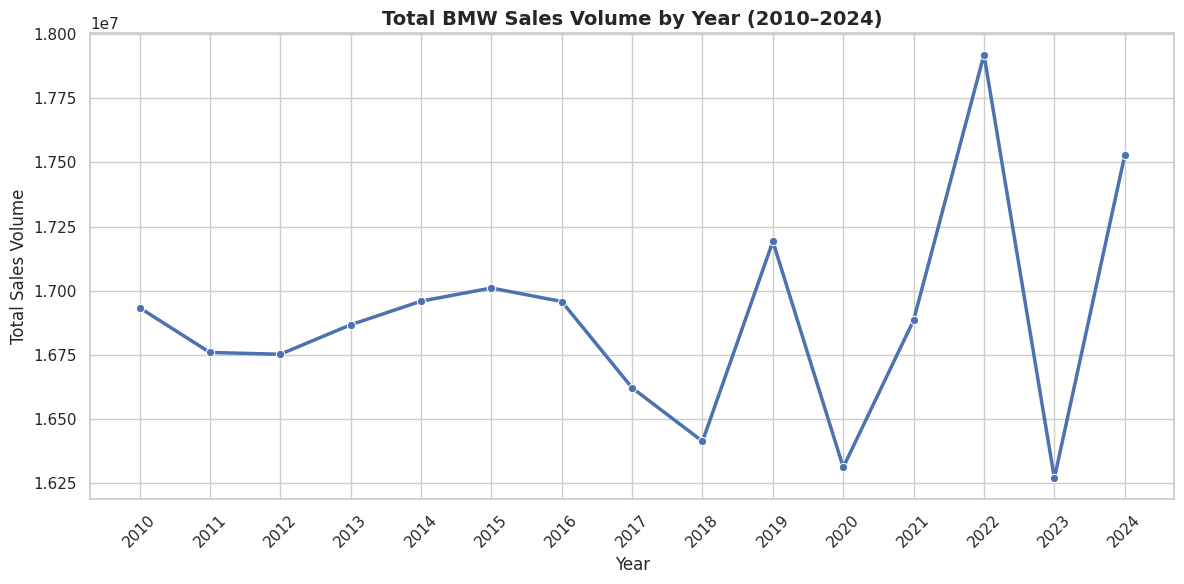

In [7]:
yearly_sales = df.groupby('Year')['Sales_Volume'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_sales, x='Year', y='Sales_Volume', marker='o', linewidth=2.5)
plt.title('Total BMW Sales Volume by Year (2010–2024)')
plt.ylabel('Total Sales Volume')
plt.xlabel('Year')
plt.xticks(yearly_sales['Year'], rotation=45)
plt.tight_layout()
plt.show()


## 8. Regional Performance

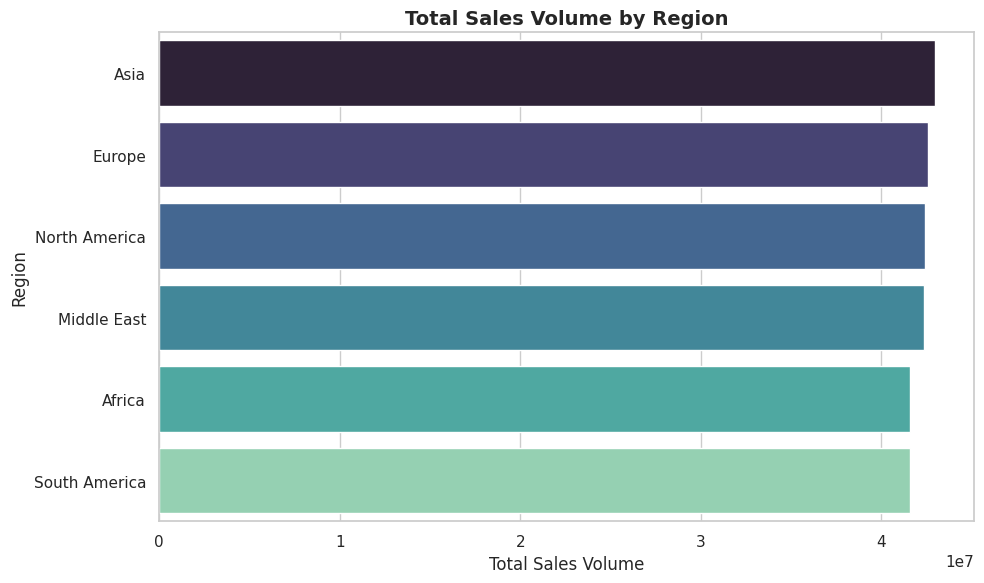

In [8]:
region_sales = df.groupby('Region')['Sales_Volume'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_sales.values, y=region_sales.index, hue=region_sales.index, palette='mako', legend=False)
plt.title('Total Sales Volume by Region')
plt.xlabel('Total Sales Volume')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


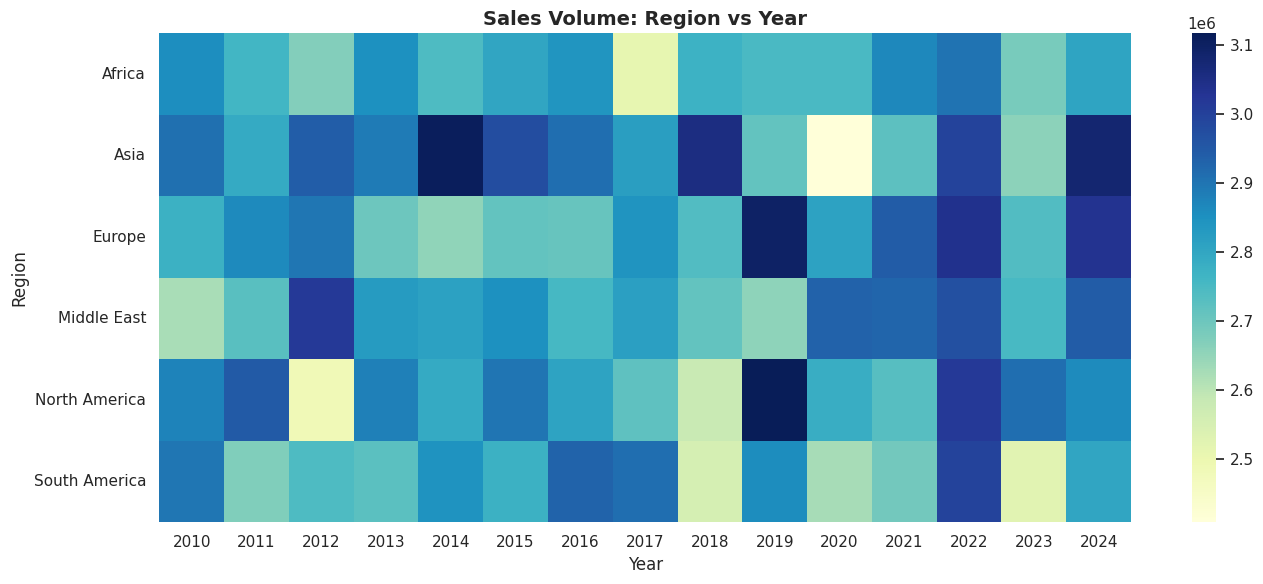

In [9]:
# Region x Year heatmap
region_year = df.pivot_table(index='Region', columns='Year', values='Sales_Volume', aggfunc='sum')

plt.figure(figsize=(14, 6))
sns.heatmap(region_year, cmap='YlGnBu', annot=False, fmt='.0f')
plt.title('Sales Volume: Region vs Year')
plt.tight_layout()
plt.show()


## 9. Model-Level Performance

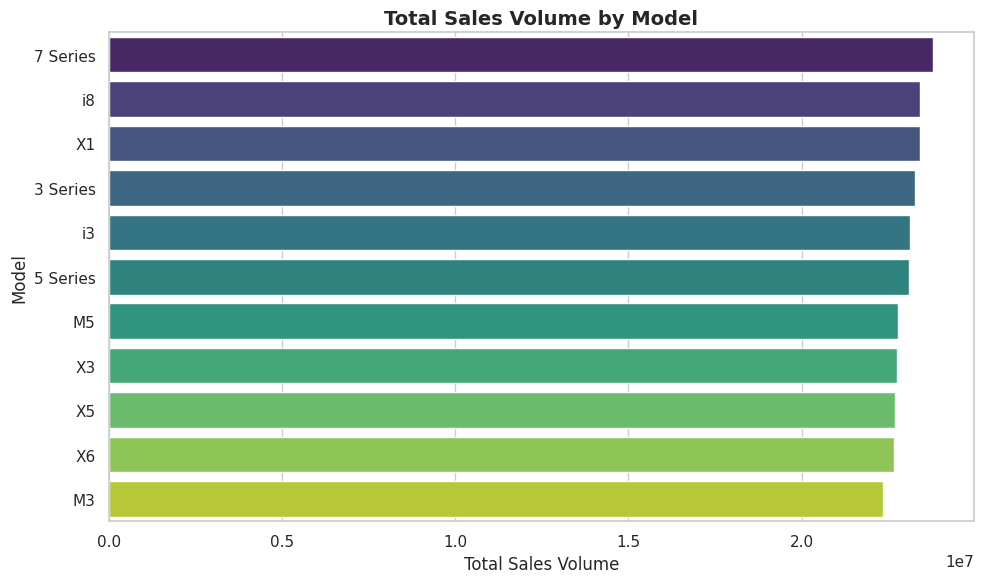

In [10]:
model_sales = df.groupby('Model')['Sales_Volume'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=model_sales.values, y=model_sales.index, hue=model_sales.index, palette='viridis', legend=False)
plt.title('Total Sales Volume by Model')
plt.xlabel('Total Sales Volume')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


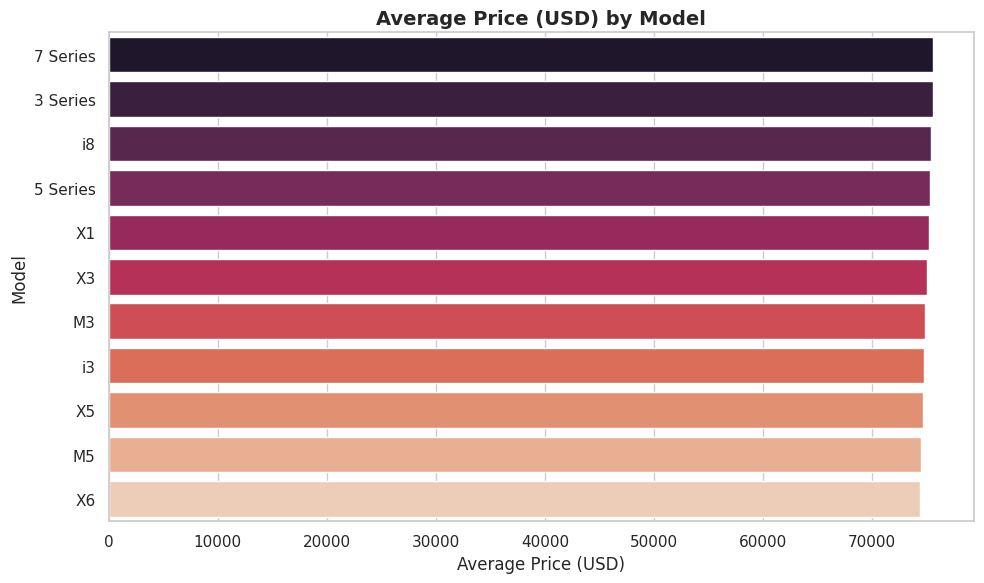

In [11]:
# Average price by model
avg_price_model = df.groupby('Model')['Price_USD'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_model.values, y=avg_price_model.index, hue=avg_price_model.index, palette='rocket', legend=False)
plt.title('Average Price (USD) by Model')
plt.xlabel('Average Price (USD)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


## 10. Fuel Type & Transmission

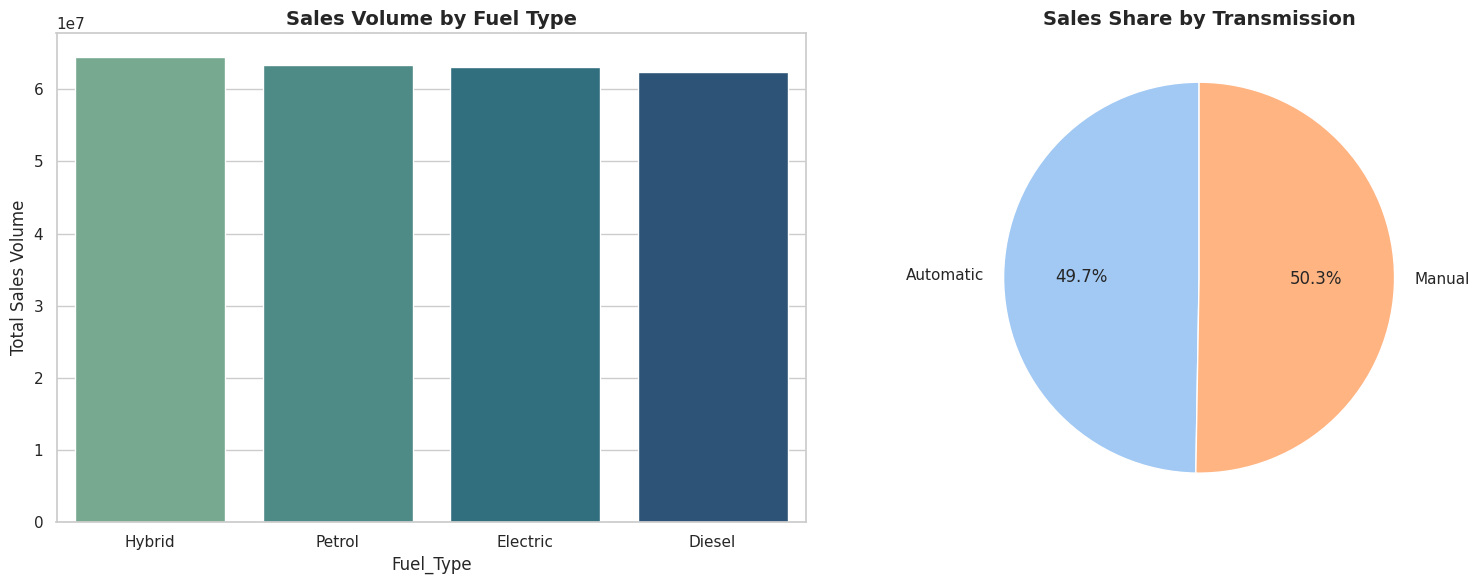

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fuel_sales = df.groupby('Fuel_Type')['Sales_Volume'].sum().sort_values(ascending=False)
sns.barplot(x=fuel_sales.index, y=fuel_sales.values, hue=fuel_sales.index, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Sales Volume by Fuel Type')
axes[0].set_ylabel('Total Sales Volume')

trans_sales = df.groupby('Transmission')['Sales_Volume'].sum()
axes[1].pie(trans_sales.values, labels=trans_sales.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=90)
axes[1].set_title('Sales Share by Transmission')

plt.tight_layout()
plt.show()


## 11. Price, Mileage & Engine Size Distributions

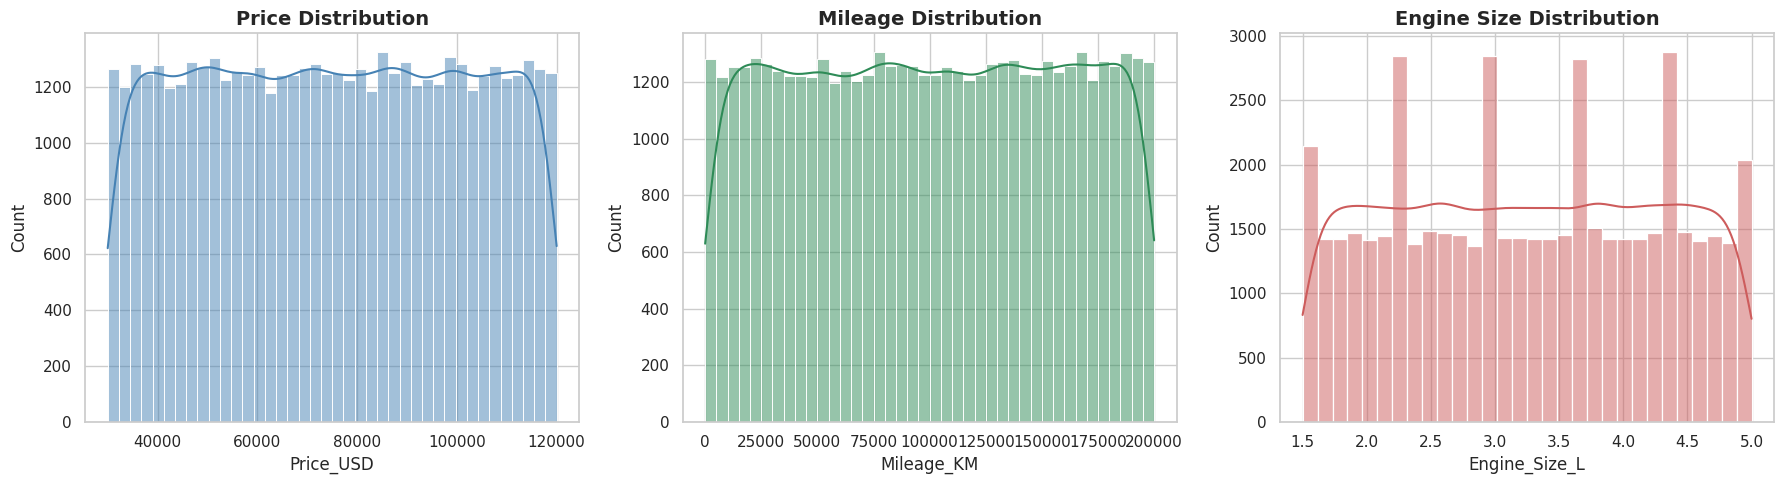

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Price_USD'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution')

sns.histplot(df['Mileage_KM'], bins=40, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Mileage Distribution')

sns.histplot(df['Engine_Size_L'], bins=30, kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Engine Size Distribution')

plt.tight_layout()
plt.show()


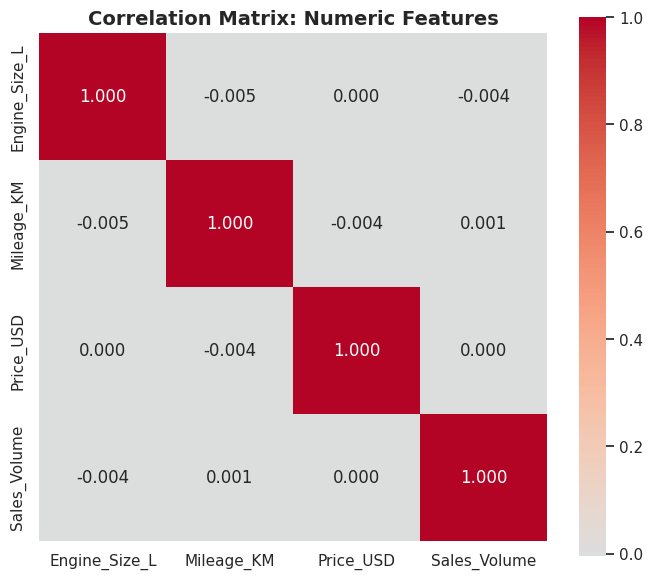

In [14]:
# Correlation heatmap of numeric features
numeric_cols = ['Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Matrix: Numeric Features')
plt.tight_layout()
plt.show()


## 12. High vs Low Sales Classification

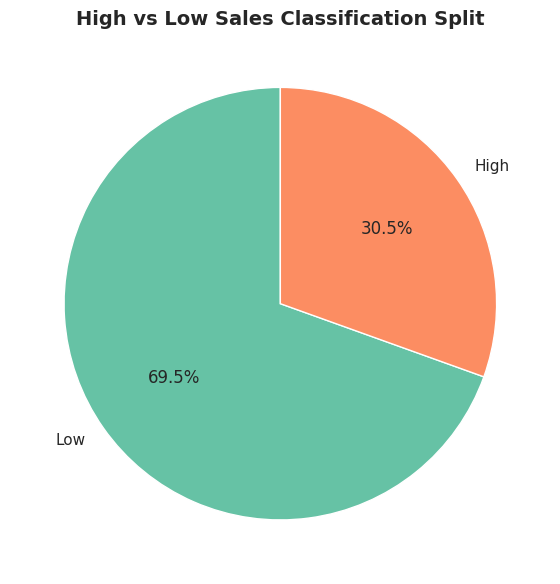

In [15]:
sc = df['Sales_Classification'].value_counts()

plt.figure(figsize=(7, 6))
plt.pie(sc.values, labels=sc.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90)
plt.title('High vs Low Sales Classification Split')
plt.tight_layout()
plt.show()


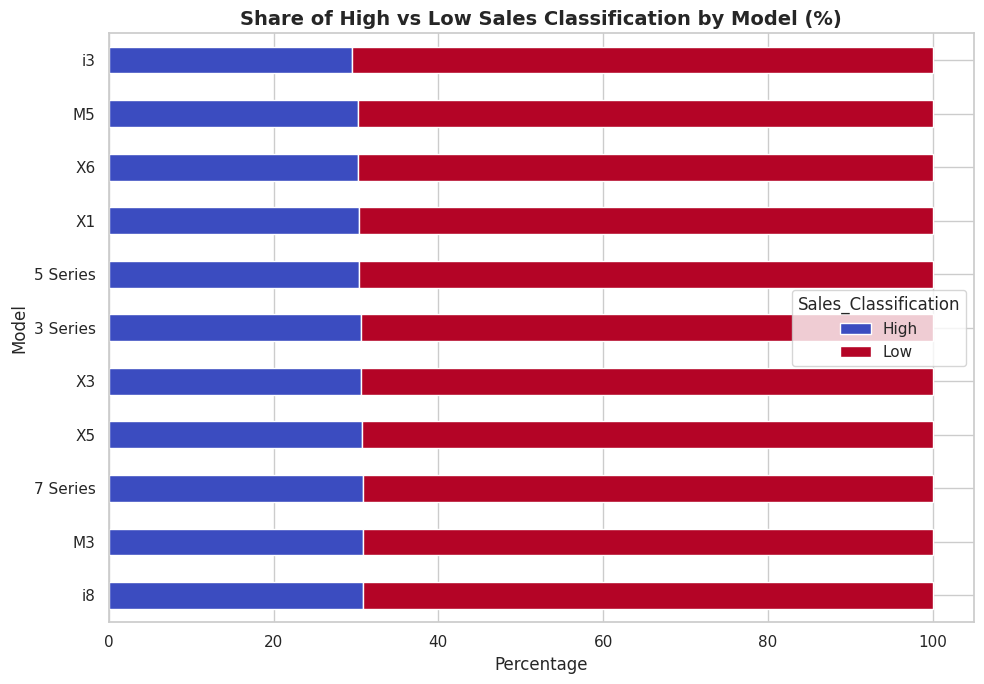

In [16]:
# Sales classification by model
class_by_model = pd.crosstab(df['Model'], df['Sales_Classification'], normalize='index') * 100

class_by_model.sort_values('High', ascending=False).plot(
    kind='barh', stacked=True, figsize=(10, 7), colormap='coolwarm'
)
plt.title('Share of High vs Low Sales Classification by Model (%)')
plt.xlabel('Percentage')
plt.tight_layout()
plt.show()


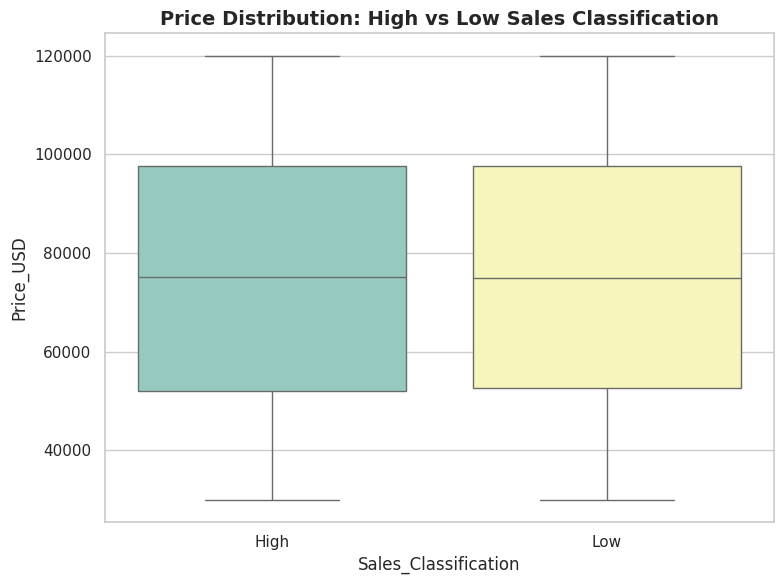

In [17]:
# Average price: High vs Low sales classification
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Sales_Classification', y='Price_USD', hue='Sales_Classification',
            palette='Set3', legend=False)
plt.title('Price Distribution: High vs Low Sales Classification')
plt.tight_layout()
plt.show()


## 13. Color Preferences

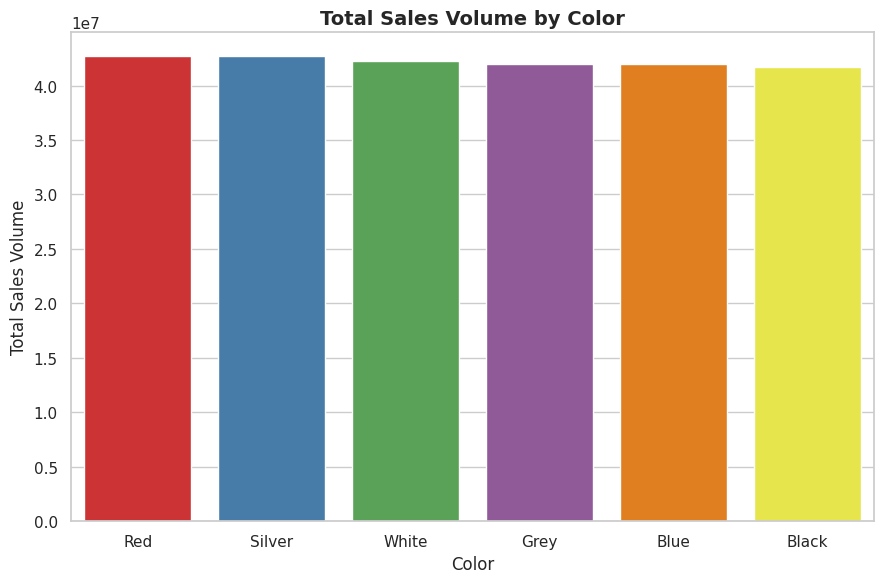

In [18]:
color_sales = df.groupby('Color')['Sales_Volume'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=color_sales.index, y=color_sales.values, hue=color_sales.index, palette='Set1', legend=False)
plt.title('Total Sales Volume by Color')
plt.ylabel('Total Sales Volume')
plt.tight_layout()
plt.show()


## 14. Region × Model Deep Dive

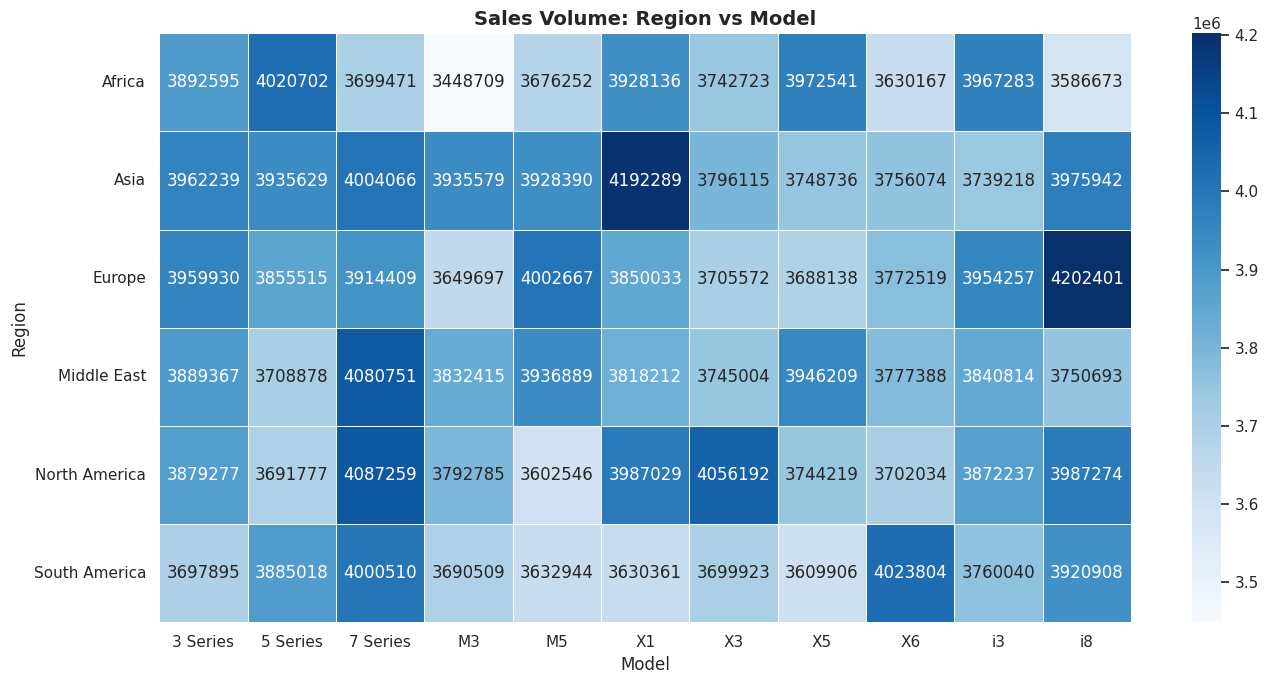

In [19]:
region_model = df.pivot_table(index='Region', columns='Model', values='Sales_Volume', aggfunc='sum')

plt.figure(figsize=(14, 7))
sns.heatmap(region_model, cmap='Blues', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Sales Volume: Region vs Model')
plt.tight_layout()
plt.show()


## 15. Key Takeaways

Fill in / adjust based on what the charts show for your run, but based on this dataset:

- **Overall scale**: ~50,000 records spanning 2010–2024, 11 BMW models, 6 regions.
- **Trend over time**: Year-over-year total sales volume is fairly flat/noisy rather than 
  showing a clear growth or decline trend — this dataset behaves like randomly generated 
  data rather than real historical BMW sales (all categories — regions, models, fuel types — 
  have near-identical total volumes, and price/mileage/engine size show ~0 correlation with 
  sales volume).
- **Regions**: Sales volume is nearly evenly split across all 6 regions.
- **Models**: All 11 models have very similar total sales volume and average price (~$74–76k).
- **Fuel type / transmission**: Roughly even split across Petrol, Diesel, Hybrid, Electric, 
  and Manual vs Automatic.
- **Sales classification**: ~30% of records are labeled "High" and ~70% "Low", and this split 
  does not track cleanly with Price, Mileage, or Engine Size (weak/near-zero correlations) — 
  suggesting the classification threshold used to generate this dataset was likely independent 
  of these numeric fields, or based on a Sales_Volume threshold not fully explained by them.

**Practical note:** if this is meant to represent real BMW sales, it's worth checking the 
data source/generation method — the near-uniform distributions across every category and 
~0 correlations are consistent with synthetically/randomly generated data rather than actual 
market sales records.
